# 05A — Lassa Mutation Scoring & Hotspot Analysis

This notebook performs **Lassa-only** mutation and hotspot analysis using:

- Lassa reference protein sequence
- Cleaned Lassa dataset FASTA
- Precomputed Lassa ESM-2 embeddings (`lassa_embeddings.pt`)
- Lassa metadata (`lassa_metadata.csv`)
- Multiple sequence alignment with reference (via MAFFT)

We will:

1. Load and validate reference, dataset, metadata, and embeddings
2. Align all Lassa sequences to the reference (if not already aligned)
3. Build a mapping from alignment positions to reference positions
4. Compute site-level conservation, entropy, and categories (Critical / Hotspot / etc.)
5. Compute substitution-level scores at each reference position (A→V vs A→D, etc.)
6. Visualize mutation hotspots along the reference protein
7. Save clean CSV outputs for downstream modeling (Step 06)

**NOTE:** This notebook is Lassa-specific. `05B` will do the same for Ebola, and `05C` will compare Lassa vs Ebola.

## SECTION 0 — Imports & Paths

Keep paths consistent with previous steps (01–04) and the `data/` layout on disk.

In [2]:
import os
import math
import time
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from Bio import SeqIO
import torch

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base data directory (update if your repo lives elsewhere)
DATA_BASE = Path("/Users/user/data")

# Lassa-specific inputs
REF_FASTA  = DATA_BASE / "Reference/Lassa_Reference_Sequence.fasta"   # adjust name if different
DATA_FASTA = DATA_BASE / "processed/lassa_cleaned.fasta"
EMB_PT     = DATA_BASE / "embeddings/lassa_embeddings.pt"
META_CSV   = DATA_BASE / "embeddings/lassa_metadata.csv"

# Outputs
OUT_DIR = DATA_BASE / "results/lassa_step05A"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Alignment-related paths
COMBINED_FASTA = DATA_BASE / "interim/lassa_ref_plus_dataset.fasta"
ALN_OUT        = DATA_BASE / "interim/lassa_with_reference_aligned.fasta"
COMBINED_FASTA.parent.mkdir(parents=True, exist_ok=True)
ALN_OUT.parent.mkdir(parents=True, exist_ok=True)

print("REF exists :", REF_FASTA.exists(), REF_FASTA)
print("DATA exists:", DATA_FASTA.exists(), DATA_FASTA)
print("EMB exists :", EMB_PT.exists(), EMB_PT)
print("META exists:", META_CSV.exists(), META_CSV)
print("OUT_DIR:", OUT_DIR)

REF exists : True /Users/user/data/Reference/Lassa_Reference_Sequence.fasta
DATA exists: True /Users/user/data/processed/lassa_cleaned.fasta
EMB exists : True /Users/user/data/embeddings/lassa_embeddings.pt
META exists: True /Users/user/data/embeddings/lassa_metadata.csv
OUT_DIR: /Users/user/data/results/lassa_step05A


## SECTION 1 — Load and Validate (Reference, Dataset, Metadata, Embeddings)

We:
- Load a **single** Lassa reference sequence
- Load all cleaned Lassa sequences (dataset)
- Load metadata and embeddings, and verify they are consistent with the FASTA dataset
- Create a design matrix `X` from embeddings for potential downstream modeling

In [3]:
def read_single_fasta(path: Path):
    recs = list(SeqIO.parse(str(path), "fasta"))
    assert len(recs) == 1, f"Expected exactly 1 sequence in {path}, found {len(recs)}"
    rec = recs[0]
    return rec.id, str(rec.seq).strip()

ref_id, ref_seq = read_single_fasta(REF_FASTA)
print("Reference ID:", ref_id)
print("Reference length:", len(ref_seq))
print("Reference preview:", ref_seq[:60], "...")

Reference ID: sp|P08669|GLYC_LASSJ
Reference length: 491
Reference preview: MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTS ...


### 1.2 — Load Lassa dataset FASTA

This should contain the exact same sequences you used to compute `lassa_embeddings.pt` and `lassa_metadata.csv`.

In [4]:
dataset_records = list(SeqIO.parse(str(DATA_FASTA), "fasta"))
print("Dataset sequences:", len(dataset_records))

data_rows = []
for rec in dataset_records:
    seq = str(rec.seq).strip()
    if seq:
        data_rows.append({"id": rec.id, "sequence": seq, "length": len(seq)})
dataset_df = pd.DataFrame(data_rows)
dataset_df.head(3)

Dataset sequences: 780


,id,sequence,length
0,X52400|s|LIII|3417,APGILGIDCAFNLLFGKCRNQDGTDCDILPRSSSCYGSDEYCPYCT...,1064
1,OL774861|s|LIII|3371,AQWILGYWIALCTNQTFGVTTFKTHGSDNHHDNECFQGSEVILVDS...,1059
2,MK107965|s|LIII|3407,IYISRRLRILEALFGDQTIRMGQIVTFFQEVPHVIEEVMNIVLIAL...,1097


### 1.3 — Load Lassa metadata + embeddings and verify consistency

We expect:

- Metadata rows = number of embeddings = number of sequences in Lassa FASTA
- IDs in `lassa_metadata.csv` match FASTA IDs
- `embedding_idx` is 0..N-1 and matches embedding row order


In [5]:
meta = pd.read_csv(META_CSV)
emb = torch.load(EMB_PT, map_location="cpu")

print("Meta:", meta.shape)
print("Emb:", type(emb), emb.shape, emb.dtype)

assert isinstance(emb, torch.Tensor) and emb.ndim == 2, "Embeddings must be 2D torch.Tensor"
assert len(meta) == emb.shape[0], "Embeddings rows must match metadata rows"
assert set(["id","sequence","embedding_idx"]).issubset(meta.columns)

# ID consistency between FASTA and metadata
fasta_ids = set(dataset_df["id"])
meta_ids = set(meta["id"])
print("ID match:", fasta_ids == meta_ids, "| FASTA:", len(fasta_ids), "| META:", len(meta_ids))

if fasta_ids != meta_ids:
    print("Missing in META (sample):", list(fasta_ids - meta_ids)[:5])
    print("Missing in FASTA (sample):", list(meta_ids - fasta_ids)[:5])
    raise ValueError("FASTA and metadata IDs do not match. Stop and fix before continuing.")

# Reorder metadata (and embeddings) to match dataset_df ID order
meta = meta.set_index("id").loc[dataset_df["id"]].reset_index()

# embedding_idx should be 0..N-1 and aligned to emb rows
assert (meta["embedding_idx"].values == np.arange(len(meta))).all(), (
    "embedding_idx is not 0..N-1 after ordering by FASTA IDs. "
    "This suggests metadata order differs from embeddings order."
)

X = emb.float()  # design matrix for downstream
print("✅ FASTA, metadata, embeddings are consistent. X shape:", X.shape)

Meta: (780, 5)
Emb: <class 'torch.Tensor'> torch.Size([780, 1280]) torch.float32
ID match: True | FASTA: 780 | META: 780
✅ FASTA, metadata, embeddings are consistent. X shape: torch.Size([780, 1280])


## SECTION 2 — Alignment with Lassa Reference

We:
- Check that MAFFT is available
- Write a combined FASTA (reference + all Lassa sequences)
- Run MAFFT to generate an MSA
- Use the alignment to map each alignment column to a reference position

This is necessary to make **reference position numbering** meaningful when scoring mutations.

In [6]:
def have_mafft():
    try:
        r = subprocess.run(["mafft", "--version"], capture_output=True, text=True)
        return r.returncode == 0
    except FileNotFoundError:
        return False

print("MAFFT available:", have_mafft())
if not have_mafft():
    raise RuntimeError(
        "MAFFT not installed.\n"
        "Install (conda): conda install -c bioconda mafft -y\n"
        "or on macOS (brew): brew install mafft\n"
        "Then restart the kernel and re-run."
    )

MAFFT available: True


### 2.1 — Write combined FASTA (reference first, then dataset)

In [7]:
print("Reference FASTA:", REF_FASTA.exists(), REF_FASTA)
print("Lassa dataset FASTA:", DATA_FASTA.exists(), DATA_FASTA)
print("Combined FASTA:", COMBINED_FASTA)
print("Aligned FASTA:", ALN_OUT)

# Write combined FASTA if it doesn't exist or you want to overwrite
COMBINED_FASTA.parent.mkdir(parents=True, exist_ok=True)

ref_recs = list(SeqIO.parse(str(REF_FASTA), "fasta"))
assert len(ref_recs) == 1, f"Expected 1 reference seq, found {len(ref_recs)}"
ref_id = ref_recs[0].id
ref_seq = str(ref_recs[0].seq).strip()

dataset_records = list(SeqIO.parse(str(DATA_FASTA), "fasta"))
print("Reference:", ref_id, "len:", len(ref_seq))
print("Dataset sequences:", len(dataset_records))

with open(COMBINED_FASTA, "w") as f:
    f.write(f">{ref_id}\n{ref_seq}\n")
    for rec in dataset_records:
        seq = str(rec.seq).strip()
        if seq:
            f.write(f">{rec.id}\n{seq}\n")

print("Wrote combined FASTA:", COMBINED_FASTA, "bytes:", COMBINED_FASTA.stat().st_size)

Reference FASTA: True /Users/user/data/Reference/Lassa_Reference_Sequence.fasta
Lassa dataset FASTA: True /Users/user/data/processed/lassa_cleaned.fasta
Combined FASTA: /Users/user/data/interim/lassa_ref_plus_dataset.fasta
Aligned FASTA: /Users/user/data/interim/lassa_with_reference_aligned.fasta
Reference: sp|P08669|GLYC_LASSJ len: 491
Dataset sequences: 780
Wrote combined FASTA: /Users/user/data/interim/lassa_ref_plus_dataset.fasta bytes: 842755


### 2.2 — Run MAFFT to create alignment (MSA)

This may take several minutes depending on sequence count and length.

In [8]:
if not ALN_OUT.exists():
    cmd = ["mafft", "--auto", str(COMBINED_FASTA)]
    print("Running:", " ".join(cmd))
    start = time.time()
    with open(ALN_OUT, "w") as f_out:
        p = subprocess.run(cmd, stdout=f_out, stderr=subprocess.PIPE, text=True)
    print("Return code:", p.returncode)
    print("MAFFT stderr tail:\n", "\n".join(p.stderr.splitlines()[-20:]))
    assert ALN_OUT.exists() and ALN_OUT.stat().st_size > 0
    print(f"✅ Alignment saved: {ALN_OUT} ({(time.time()-start)/60:.1f} min)")
else:
    print("✅ Alignment already exists:", ALN_OUT)

✅ Alignment already exists: /Users/user/data/interim/lassa_with_reference_aligned.fasta


## SECTION 3 — Build Reference Coordinate Mapping

We map each alignment column → reference position (1-based). Columns where the reference has a gap are mapped to `None` and ignored for reference-based scoring.

In [9]:
GAP = "-"
AA_SET = set("ACDEFGHIKLMNPQRSTVWY")
AAS = list("ACDEFGHIKLMNPQRSTVWY")

aligned = list(SeqIO.parse(str(ALN_OUT), "fasta"))
assert aligned[0].id == ref_id, "Reference must be first record in alignment"

aln_ref_seq = str(aligned[0].seq)
aln_len = len(aln_ref_seq)
assert all(len(str(r.seq)) == aln_len for r in aligned)

dataset_aligned = [str(r.seq) for r in aligned[1:]]  # exclude reference
print("Aligned dataset sequences:", len(dataset_aligned))
print("Alignment length:", aln_len)

# mapping: alignment column -> reference position (1-based), None if ref has gap
aln_to_refpos = [None] * aln_len
ref_pos = 0
for i, ch in enumerate(aln_ref_seq):
    if ch != GAP:
        ref_pos += 1
        aln_to_refpos[i] = ref_pos

assert ref_pos == len(ref_seq), "Reference length from alignment must match REF_FASTA"
print("✅ Built aln_to_refpos mapping. ref length:", ref_pos)

Aligned dataset sequences: 780
Alignment length: 3269
✅ Built aln_to_refpos mapping. ref length: 491


## SECTION 4 — Site-level Scores: Conservation, Entropy, Hotspots

For each reference position, we compute:

- `gap_rate` (fraction of alignment sequences with a gap at that column)
- `nongap_count` (number of non-gap residues)
- `conservation` (frequency of the most common amino acid)
- `entropy` (Shannon entropy among amino acids, excluding gaps)
- `top_aas` (top amino acids and counts)
- `site_category`: MostlyGap, Critical, Conserved, Hotspot, Intermediate

This tells us **where Lassa is conserved vs variable** along the reference.

In [10]:
def shannon_entropy(counts: dict):
    total = sum(counts.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for c in counts.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent

rows = []
N = len(dataset_aligned)

for aln_i in range(aln_len):
    refpos = aln_to_refpos[aln_i]
    if refpos is None:
        continue

    ref_aa = aln_ref_seq[aln_i]
    col = [s[aln_i] for s in dataset_aligned]
    counts_all = Counter(col)

    gap_count = counts_all.get(GAP, 0)
    aa_counts = {aa: c for aa, c in counts_all.items() if aa in AA_SET}
    total_aa = sum(aa_counts.values())

    if total_aa == 0:
        consensus = "-"
        conservation = 0.0
        entropy = 0.0
        top_aas = ""
    else:
        consensus, cons_count = max(aa_counts.items(), key=lambda x: x[1])
        conservation = cons_count / total_aa
        entropy = shannon_entropy(aa_counts)
        top = sorted(aa_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        top_aas = ";".join([f"{a}:{c}" for a, c in top])

    rows.append({
        "ref_pos": int(refpos),
        "ref_aa": ref_aa,
        "consensus_aa": consensus,
        "gap_rate": gap_count / N,
        "nongap_count": int(total_aa),
        "conservation": float(conservation),
        "entropy": float(entropy),
        "top_aas": top_aas,
    })

site_df = pd.DataFrame(rows).sort_values("ref_pos").reset_index(drop=True)
print(site_df.shape)
site_df.head(5)

(491, 8)


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas
0,1,M,M,0.487179,400,0.675000,1.566804,M:270;V:75;S:17;E:15;P:10
1,2,G,G,0.484615,402,0.850746,1.061568,G:342;K:12;R:12;S:11;W:10
2,3,Q,Q,0.484615,402,0.684080,1.623073,Q:275;F:68;C:15;E:12;L:11
3,4,I,I,0.478205,407,0.879607,0.859922,I:358;P:15;K:10;T:8;L:5
4,5,V,I,0.365385,495,0.404040,2.685139,I:200;K:91;V:77;L:38;S:19


### 4.1 — Label Sites (Critical / Hotspot / etc.)

Heuristics (can be tuned later, e.g. by domain experts):

- **MostlyGap**: `gap_rate > 0.5`
- **Critical**: `conservation ≥ 0.95` and `gap_rate ≤ 0.10`
- **Conserved**: `conservation ≥ 0.80` (but not Critical)
- **Hotspot**: high entropy (top 10% of entropy) or low conservation (`≤ 0.50`)
- **Intermediate**: everything else

In [11]:
entropy_hotspot_threshold = site_df["entropy"].quantile(0.90)

def site_category(row):
    if row["gap_rate"] > 0.5:
        return "MostlyGap"
    if row["conservation"] >= 0.95 and row["gap_rate"] <= 0.10:
        return "Critical"
    if row["conservation"] >= 0.80:
        return "Conserved"
    if row["entropy"] >= entropy_hotspot_threshold or row["conservation"] <= 0.50:
        return "Hotspot"
    return "Intermediate"

site_df["site_category"] = site_df.apply(site_category, axis=1)
site_df["site_category"].value_counts()

site_category
Intermediate    200
Hotspot         171
MostlyGap        84
Conserved        34
Critical          2
Name: count, dtype: int64

### 4.2 — Save Lassa Site-level Table

We will reuse this in 05C (Lassa vs Ebola comparison) and in Step 06 (model building).

In [12]:
out_site = OUT_DIR / "Lassa_site_scores_reference_based.csv"
site_df.to_csv(out_site, index=False)
print("Saved:", out_site.resolve())
site_df.head(5)

Saved: /Users/user/data/results/lassa_step05A/Lassa_site_scores_reference_based.csv


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category
0,1,M,M,0.487179,400,0.675000,1.566804,M:270;V:75;S:17;E:15;P:10,Intermediate
1,2,G,G,0.484615,402,0.850746,1.061568,G:342;K:12;R:12;S:11;W:10,Conserved
2,3,Q,Q,0.484615,402,0.684080,1.623073,Q:275;F:68;C:15;E:12;L:11,Intermediate
3,4,I,I,0.478205,407,0.879607,0.859922,I:358;P:15;K:10;T:8;L:5,Conserved
4,5,V,I,0.365385,495,0.404040,2.685139,I:200;K:91;V:77;L:38;S:19,Hotspot


## SECTION 5 — Substitution-level Table (Per-position Mutation Scoring)

For each reference position and each possible amino acid `mut_aa` (A, C, D, ...), we compute:

- Whether it is observed in the alignment
- Its frequency
- BLOSUM62 substitution score (`ref_aa → mut_aa`)
- Categories based on conservation context (e.g. more concerning in Critical sites)

This answers: *“If this position mutates from A to V vs from A to D, which is more harmful?”* (heuristically).

In [13]:
# BLOSUM62 table (20 AAs)
BLOSUM62 = {
"A":{"A":4,"R":-1,"N":-2,"D":-2,"C":0,"Q":-1,"E":-1,"G":0,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":0,"W":-3,"Y":-2,"V":0},
"R":{"A":-1,"R":5,"N":0,"D":-2,"C":-3,"Q":1,"E":0,"G":-2,"H":0,"I":-3,"L":-2,"K":2,"M":-1,"F":-3,"P":-2,"S":-1,"T":-1,"W":-3,"Y":-2,"V":-3},
"N":{"A":-2,"R":0,"N":6,"D":1,"C":-3,"Q":0,"E":0,"G":0,"H":1,"I":-3,"L":-3,"K":0,"M":-2,"F":-3,"P":-2,"S":1,"T":0,"W":-4,"Y":-2,"V":-3},
"D":{"A":-2,"R":-2,"N":1,"D":6,"C":-3,"Q":0,"E":2,"G":-1,"H":-1,"I":-3,"L":-4,"K":-1,"M":-3,"F":-3,"P":-1,"S":0,"T":-1,"W":-4,"Y":-3,"V":-3},
"C":{"A":0,"R":-3,"N":-3,"D":-3,"C":9,"Q":-3,"E":-4,"G":-3,"H":-3,"I":-1,"L":-1,"K":-3,"M":-1,"F":-2,"P":-3,"S":-1,"T":-1,"W":-2,"Y":-2,"V":-1},
"Q":{"A":-1,"R":1,"N":0,"D":0,"C":-3,"Q":5,"E":2,"G":-2,"H":0,"I":-3,"L":-2,"K":1,"M":0,"F":-3,"P":-1,"S":0,"T":-1,"W":-2,"Y":-1,"V":-2},
"E":{"A":-1,"R":0,"N":0,"D":2,"C":-4,"Q":2,"E":5,"G":-2,"H":0,"I":-3,"L":-3,"K":1,"M":-2,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"G":{"A":0,"R":-2,"N":0,"D":-1,"C":-3,"Q":-2,"E":-2,"G":6,"H":-2,"I":-4,"L":-4,"K":-2,"M":-3,"F":-3,"P":-2,"S":0,"T":-2,"W":-2,"Y":-3,"V":-3},
"H":{"A":-2,"R":0,"N":1,"D":-1,"C":-3,"Q":0,"E":0,"G":-2,"H":8,"I":-3,"L":-3,"K":-1,"M":-2,"F":-1,"P":-2,"S":-1,"T":-2,"W":-2,"Y":2,"V":-3},
"I":{"A":-1,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-3,"E":-3,"G":-4,"H":-3,"I":4,"L":2,"K":-3,"M":1,"F":0,"P":-3,"S":-2,"T":-1,"W":-3,"Y":-1,"V":3},
"L":{"A":-1,"R":-2,"N":-3,"D":-4,"C":-1,"Q":-2,"E":-3,"G":-4,"H":-3,"I":2,"L":4,"K":-2,"M":2,"F":0,"P":-3,"S":-2,"T":-1,"W":-2,"Y":-1,"V":1},
"K":{"A":-1,"R":2,"N":0,"D":-1,"C":-3,"Q":1,"E":1,"G":-2,"H":-1,"I":-3,"L":-2,"K":5,"M":-1,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"M":{"A":-1,"R":-1,"N":-2,"D":-3,"C":-1,"Q":0,"E":-2,"G":-3,"H":-2,"I":1,"L":2,"K":-1,"M":5,"F":0,"P":-2,"S":-1,"T":-1,"W":-1,"Y":-1,"V":1},
"F":{"A":-2,"R":-3,"N":-3,"D":-3,"C":-2,"Q":-3,"E":-3,"G":-3,"H":-1,"I":0,"L":0,"K":-3,"M":0,"F":6,"P":-4,"S":-2,"T":-2,"W":1,"Y":3,"V":-1},
"P":{"A":-1,"R":-2,"N":-2,"D":-1,"C":-3,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-3,"L":-3,"K":-1,"M":-2,"F":-4,"P":7,"S":-1,"T":-1,"W":-4,"Y":-3,"V":-2},
"S":{"A":1,"R":-1,"N":1,"D":0,"C":-1,"Q":0,"E":0,"G":0,"H":-1,"I":-2,"L":-2,"K":0,"M":-1,"F":-2,"P":-1,"S":4,"T":1,"W":-3,"Y":-2,"V":-2},
"T":{"A":0,"R":-1,"N":0,"D":-1,"C":-1,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":5,"W":-2,"Y":-2,"V":0},
"W":{"A":-3,"R":-3,"N":-4,"D":-4,"C":-2,"Q":-2,"E":-3,"G":-2,"H":-2,"I":-3,"L":-2,"K":-3,"M":-1,"F":1,"P":-4,"S":-3,"T":-2,"W":11,"Y":2,"V":-3},
"Y":{"A":-2,"R":-2,"N":-2,"D":-3,"C":-2,"Q":-1,"E":-2,"G":-3,"H":2,"I":-1,"L":-1,"K":-2,"M":-1,"F":3,"P":-3,"S":-2,"T":-2,"W":2,"Y":7,"V":-1},
"V":{"A":0,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-2,"E":-2,"G":-3,"H":-3,"I":3,"L":1,"K":-2,"M":1,"F":-1,"P":-2,"S":-2,"T":0,"W":-3,"Y":-1,"V":4}
}

def blosum_score(ref_aa, mut_aa):
    if ref_aa not in BLOSUM62 or mut_aa not in BLOSUM62[ref_aa]:
        return None
    return BLOSUM62[ref_aa][mut_aa]

# Quick sanity
print("BLOSUM62 A->V:", blosum_score("A", "V"))
print("BLOSUM62 A->D:", blosum_score("A", "D"))

BLOSUM62 A->V: 0
BLOSUM62 A->D: -2


In [14]:
sub_rows = []

for aln_i in range(aln_len):
    refpos = aln_to_refpos[aln_i]
    if refpos is None:
        continue

    ref_aa = aln_ref_seq[aln_i]
    col = [s[aln_i] for s in dataset_aligned]
    counts_all = Counter(col)
    aa_counts = {aa: c for aa, c in counts_all.items() if aa in AA_SET}
    total_aa = sum(aa_counts.values())
    if total_aa == 0:
        continue

    for mut_aa in AA_SET:
        c = aa_counts.get(mut_aa, 0)
        freq = c / total_aa
        score = blosum_score(ref_aa, mut_aa)
        observed = c > 0

        sub_rows.append({
            "ref_pos": int(refpos),
            "ref_aa": ref_aa,
            "mut_aa": mut_aa,
            "count": int(c),
            "freq": float(freq),
            "blosum62": score,
            "observed": observed,
        })

sub_df = pd.DataFrame(sub_rows)
print(sub_df.shape)
sub_df.head(10)

(9820, 7)


,ref_pos,ref_aa,mut_aa,count,freq,blosum62,observed
0,1,M,V,75,0.1875,1,True
1,1,M,R,0,0.0000,-1,False
2,1,M,P,10,0.0250,-2,True
3,1,M,T,1,0.0025,-1,True
4,1,M,G,0,0.0000,-3,False
5,1,M,Y,0,0.0000,-1,False
6,1,M,C,1,0.0025,-1,True
7,1,M,L,5,0.0125,2,True
8,1,M,Q,0,0.0000,0,False
9,1,M,M,270,0.6750,5,True


### 5.2 — Add Site Category and Simple Impact Flag

We join site-level categories onto the substitution-level table and define a very simple **impact label** (this is heuristic and can be refined later in Step 06):

- **HighImpact**: occurs at Critical site, BLOSUM62 ≤ -1, and either observed or frequency > 0.01
- **LowImpact**: occurs at Critical / Conserved with BLOSUM62 ≥ 0
- **Neutral/Other**: everything else

This will be used for training and explaining a model later (Step 06).

In [15]:
# Merge site category into substitution table
sub_df = sub_df.merge(site_df[["ref_pos", "site_category"]], on="ref_pos", how="left")

def impact_label(row):
    cat = row["site_category"]
    s = row["blosum62"]
    f = row["freq"]
    obs = row["observed"]
    
    if s is None:
        return "Unknown"
    
    if cat == "Critical" and s <= -1 and (obs or f > 0.01):
        return "HighImpact"
    if cat in {"Critical", "Conserved"} and s >= 0:
        return "LowImpact"
    if cat == "Hotspot" and s <= -1:
        return "HotspotNegative"
    return "Intermediate"

sub_df["impact_label"] = sub_df.apply(impact_label, axis=1)
sub_df["impact_label"].value_counts().head(10)

impact_label
Intermediate       7225
HotspotNegative    2373
LowImpact           213
HighImpact            9
Name: count, dtype: int64

### 5.3 — Save Substitution-level Table

This table is the core of **mutation scoring** for Lassa and will be merged with model predictions in Step 06.

In [16]:
out_sub = OUT_DIR / "Lassa_substitution_scores_reference_based.csv"
sub_df.to_csv(out_sub, index=False)
print("Saved:", out_sub.resolve())
sub_df.head(10)

Saved: /Users/user/data/results/lassa_step05A/Lassa_substitution_scores_reference_based.csv


,ref_pos,ref_aa,mut_aa,count,freq,blosum62,observed,site_category,impact_label
0,1,M,V,75,0.1875,1,True,Intermediate,Intermediate
1,1,M,R,0,0.0000,-1,False,Intermediate,Intermediate
2,1,M,P,10,0.0250,-2,True,Intermediate,Intermediate
3,1,M,T,1,0.0025,-1,True,Intermediate,Intermediate
4,1,M,G,0,0.0000,-3,False,Intermediate,Intermediate
5,1,M,Y,0,0.0000,-1,False,Intermediate,Intermediate
6,1,M,C,1,0.0025,-1,True,Intermediate,Intermediate
7,1,M,L,5,0.0125,2,True,Intermediate,Intermediate
8,1,M,Q,0,0.0000,0,False,Intermediate,Intermediate
9,1,M,M,270,0.6750,5,True,Intermediate,Intermediate


## SECTION 6 — Visualizations: Mutation Hotspots Along Lassa Reference

We produce a few high-level plots:

1. Conservation vs reference position
2. Entropy vs reference position
3. Site category stripes along the reference

This will help us **interpret** where Lassa is stable or variable and prepare for comparison to Ebola (05C) and model building (06).

Saved: /Users/user/data/results/lassa_step05A/figures/Lassa_conservation_entropy.png


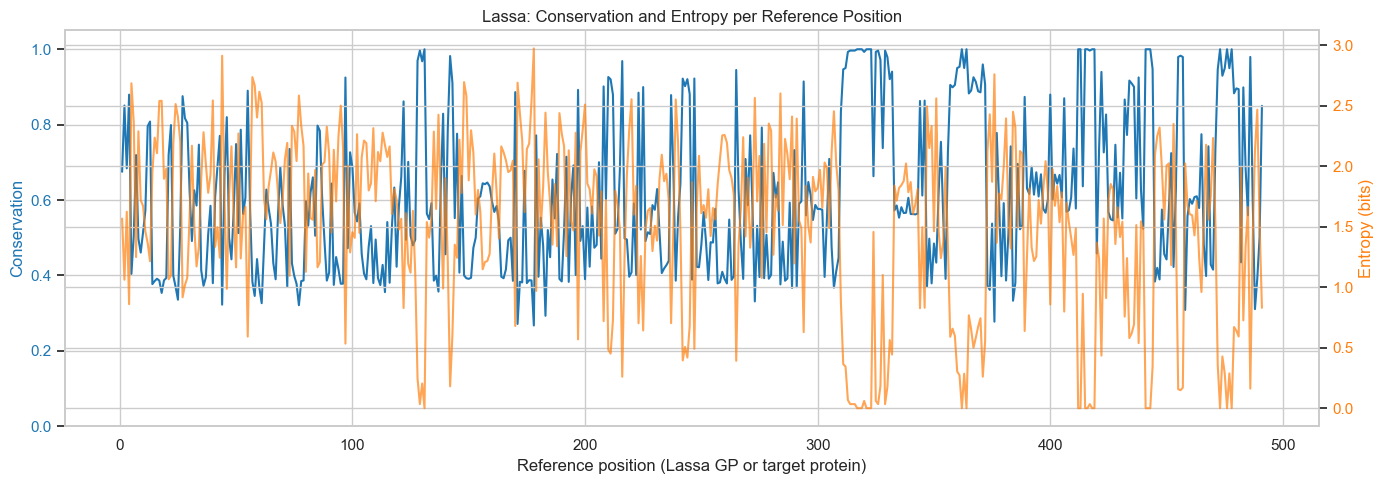

In [17]:
# 6.1 — Conservation & Entropy along the sequence
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(site_df["ref_pos"], site_df["conservation"], label="Conservation", color="tab:blue")
ax1.set_xlabel("Reference position (Lassa GP or target protein)")
ax1.set_ylabel("Conservation", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(site_df["ref_pos"], site_df["entropy"], label="Entropy", color="tab:orange", alpha=0.7)
ax2.set_ylabel("Entropy (bits)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Lassa: Conservation and Entropy per Reference Position")
fig.tight_layout()

fig_path = FIG_DIR / "Lassa_conservation_entropy.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path.resolve())
plt.show()

Saved: /Users/user/data/results/lassa_step05A/figures/Lassa_site_categories.png


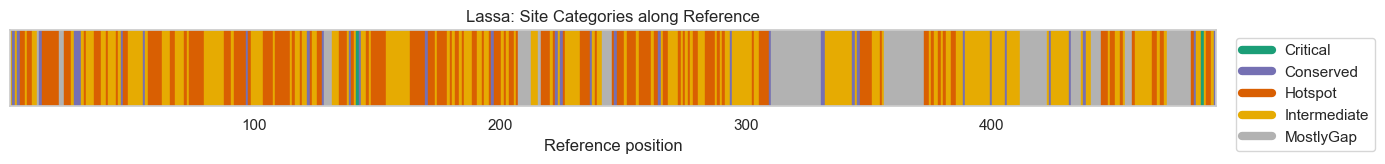

In [18]:
# 6.2 — Site category along the sequence (as a colored stripe plot)
fig, ax = plt.subplots(figsize=(14, 1.8))

cat_colors = {
    "Critical": "#1b9e77",
    "Conserved": "#7570b3",
    "Hotspot": "#d95f02",
    "Intermediate": "#e6ab02",
    "MostlyGap": "#b2b2b2",
}

for _, row in site_df.iterrows():
    c = cat_colors.get(row["site_category"], "#b2b2b2")
    ax.axvspan(row["ref_pos"] - 0.5, row["ref_pos"] + 0.5, color=c)

ax.set_xlim(0.5, site_df["ref_pos"].max() + 0.5)
ax.set_yticks([])
ax.set_xlabel("Reference position")
ax.set_title("Lassa: Site Categories along Reference")

handles = [plt.Line2D([0], [0], color=col, lw=6) for col in cat_colors.values()]
labels = list(cat_colors.keys())
ax.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left")

fig.tight_layout()
fig_path = FIG_DIR / "Lassa_site_categories.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path.resolve())
plt.show()

## SECTION 7 — Summary & Next Steps

### What we produced (Lassa-only)

1. **Site-level table** — `Lassa_site_scores_reference_based.csv`
    - One row per reference position
    - Columns: `ref_pos`, `ref_aa`, `consensus_aa`, `gap_rate`, `nongap_count`, `conservation`, `entropy`, `top_aas`, `site_category`

2. **Substitution-level table** — `Lassa_substitution_scores_reference_based.csv`
    - One row per (`ref_pos`, `ref_aa`, `mut_aa`)
    - Columns: `count`, `freq`, `blosum62`, `observed`, `site_category`, `impact_label`

3. **Figures** (in `results/lassa_step05A/figures/`):
    - `Lassa_conservation_entropy.png` — conservation + entropy vs reference position
    - `Lassa_site_categories.png` — category stripe plot along the reference

### How this connects to 05B, 05C, and 06

- **05B — Ebola Mutation Scoring & Hotspot Analysis**
    - Runs the same pipeline for Ebola (already partly implemented as `04B — Ebola Hybrid Mutation Scoring...`)

- **05C — Lassa vs Ebola Comparison**
    - Will ingest the Lassa and Ebola site-level and substitution-level CSVs
    - Align their reference numbering (if using homologous proteins)
    - Compare conservation, entropy, and hotspot patterns side-by-side

- **06 — Predictive Model & Interactive Mutation Explainer**
    - Will load embeddings (Lassa, Ebola), metadata, and mutation tables
    - Train models to predict impact / category of mutations
    - Provide end-to-end explanation: given reference + new sequence, identify mutations, link to site/impact category, and visualize where they fall in Lassa vs Ebola landscapes.

You can now proceed to:

- `05B — Ebola Mutation Scoring & Hotspot Analysis.ipynb` (Ebola-only version)
- `05C — Lassa vs Ebola Comparative Mutation Landscape.ipynb` (comparison)
